In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.anova import anova_lm
import statsmodels.formula.api as smf

In [2]:
def cohen_glass_hedges(x,y):
    nx = len(x)
    ny = len(y)
    pstdnmr = (nx-1)*x.var(ddof=1) + (ny-1)*y.var(ddof=1)   # (n-1)(var1+var2)
    pstddnm = nx + ny - 2                                   # (n-1)*2
    pstd = (pstdnmr / pstddnm)**(0.5)
    cohen = (x.mean() - y.mean()) / pstd
    glass = (x.mean() - y.mean()) / x.std(ddof=1)
    hedges = cohen * (1 - 3/(4 * (nx+ny) - 9) )             # cohen * (1-3/(8*n-9))
    return (cohen, glass, hedges)

In [3]:
w = pd.read_csv('ws.csv')

In [4]:
w.id = w.id.str.replace('w', '')

In [5]:
wm = w.melt(id_vars=['Index', 'id', 'group', 'time', 'rank', 'total'], 
            value_vars=w.columns[6:],
            var_name='step',
            value_name='val')

In [6]:
wmf=wm.copy()
wmf['avg'] = wmf['total']/19
wmf[['Index', 'id', 'rank', 'total', 'step', 'val']] = wmf[['Index', 'id', 'rank','total', 'step', 'val']].astype(float)

In [74]:
descr = w.groupby('time').total.agg(['count', 'sum', 'median', 'mean', 'min', 'max', 'std', 'var'])

In [78]:
descr['kurtosis'] = w.groupby('time').total.apply(st.kurtosis)
descr['skew'] = w.groupby('time').total.apply(st.skew)
descr[['shapiro statistic', 'shapiro p value']] = w.groupby('time').total.apply(st.shapiro)

/tmp/ipykernel_323957/2211174315.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  descr[['shapiro statistic', 'shapiro p value']] = w.groupby('time').total.apply(st.shapiro)
/tmp/ipykernel_323957/2211174315.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  descr[['shapiro statistic', 'shapiro p value']] = w.groupby('time').total.apply(st.shapiro)


In [80]:
descr['sum'] = 39

In [81]:
descr

,count,sum,median,mean,min,max,std,var,kurtosis,skew,shapiro statistic,shapiro p value
time,,,,,,,,,,,,
final,40,39,11.810,11.9395,9.63,15.88,1.584965,2.512113,-0.012353,0.621823,0.952099,0.852365
initial,40,39,12.055,12.2845,9.74,20.62,2.027411,4.110395,5.404943,1.854259,0.089564,0.000103


In [83]:
descr.T.to_csv('witty-descrT.csv')

In [7]:
AnovaRM(data=wm, depvar='val',
                 subject='id',
                 within=['time', 'step']).fit().summary()
# Two-way repeated-measures ANOVA, fully within design

,F Value,Num DF,Den DF,Pr > F
time,0.6578,1.0000,39.0000,0.4223
step,1.8220,18.0000,702.0000,0.0196
time:step,0.9587,18.0000,702.0000,0.5065


In [8]:
model = smf.ols('val ~ time * step', data=wm)
print(anova_lm(model.fit(), typ=2))
# Two-way ANOVA, fully between design
# No random effects, just fixed effects
# No linear mixed model equivalent, just linear regression

              sum_sq      df         F    PR(>F)
time        0.125289     1.0  2.703449  0.100344
step        1.360711    18.0  1.631162  0.045635
time:step   0.638223    18.0  0.765074  0.743213
Residual   68.682275  1482.0       NaN       NaN


In [9]:
ss_array = []

ss_array = ss_array + [model.fit().centered_tss]
# total sum of squares = total variation

ss_array = ss_array + [model.fit().ssr]
# residual sum of squares = SSError = within group variation

ss_array = ss_array + [model.fit().ess]
# explained sum of squares = TSS - SSR = SStime + SSstep + SSinteraction

ss_array = ss_array + [model.fit().centered_tss - smf.ols('val ~ time', data=wm).fit().ssr]
# tss - ssr of a model which has only one factor
# = explained sum of squares of that model
# = variation due to that component

ss_array = ss_array + [model.fit().centered_tss - smf.ols('val ~ step', data=wm).fit().ssr]
# same for the other component

ss_array = ss_array + [model.fit().ess - smf.ols('val ~ step + time', data=wm).fit().ess]
# explained sum of squares of full model - 
# explained sum of squares of no interactions model =
# sum of squares of interaction

ss_array

[np.float64(70.80649894736842),
 np.float64(68.682275),
 np.float64(2.124223947368421),
 np.float64(0.12528947368420518),
 np.float64(1.3607114473684305),
 np.float64(0.6382230263157993)]

In [10]:
smf.mixedlm('val ~ time', wm, groups=wm['id'], vc_formula={'step' : '1', }).fit().summary()

/home/thal/.0/STATS/venv/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
          Mixed Linear Model Regression Results
=========================================================
Model:             MixedLM  Dependent Variable:  val     
No. Observations:  1520     Method:              REML    
No. Groups:        40       Scale:               0.0436  
Min. group size:   38       Log-Likelihood:      191.6585
Max. group size:   38       Converged:           Yes     
Mean group size:   38.0                                  
---------------------------------------------------------
                Coef. Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept       0.628    0.012 54.549 0.000  0.606  0.651
time[T.initial] 0.018    0.011  1.695 0.090 -0.003  0.039
step Var        0.003    0.005                           
=========================================================

"""

In [101]:
smf.mixedlm('val ~ time * step', wm, groups=wm['id'],re_formula='~time', vc_formula={'step' : '1', }).fit().summary().tables[0]
# ,re_formula='~time', vc_formula={'step' : '1', }

/home/thal/.0/STATS/venv/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


,0,1,2,3
0,Model:,MixedLM,Dependent Variable:,val
1,No. Observations:,1520,Method:,REML
2,No. Groups:,40,Scale:,0.0392
3,Min. group size:,38,Log-Likelihood:,169.7028
4,Max. group size:,38,Converged:,Yes
5,Mean group size:,38.0,,


In [12]:
st.ttest_rel(w.loc[:39,'total'],w.loc[40:,'total'])
# t-test for subject averages (40 initial vs 40 final)

TtestResult(statistic=np.float64(0.8110552079799727), pvalue=np.float64(0.42225619346826915), df=np.int64(39))

In [13]:
cohen_glass_hedges(w.loc[:39,'total'],w.loc[40:,'total'])[0]

np.float64(0.18959325118601736)

In [14]:
st.levene(w.loc[:39,'total'],w.loc[40:,'total'])

LeveneResult(statistic=np.float64(0.3694733109378813), pvalue=np.float64(0.5450572682539253))

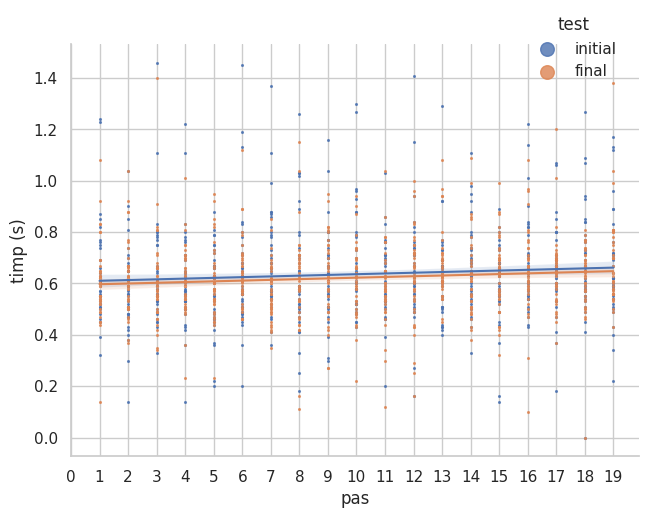

In [ ]:
sns.lmplot(wmf.drop(wmf.loc[wmf.val > 1.5].index), x='step', y='val', hue ='time', legend=False,            
           scatter_kws={"s": 1.5}, line_kws={"lw": 1.5}, order=1,
           height=5, aspect=1.33).set(xticks=range(0, 20, 1))
plt.xlabel('pas')
plt.ylabel('timp (s)')
plt.legend(title='test', loc=[0.8,0.9], markerscale=8, frameon=False)
# plt.savefig('witty-reg.svg', bbox_inches = 'tight')

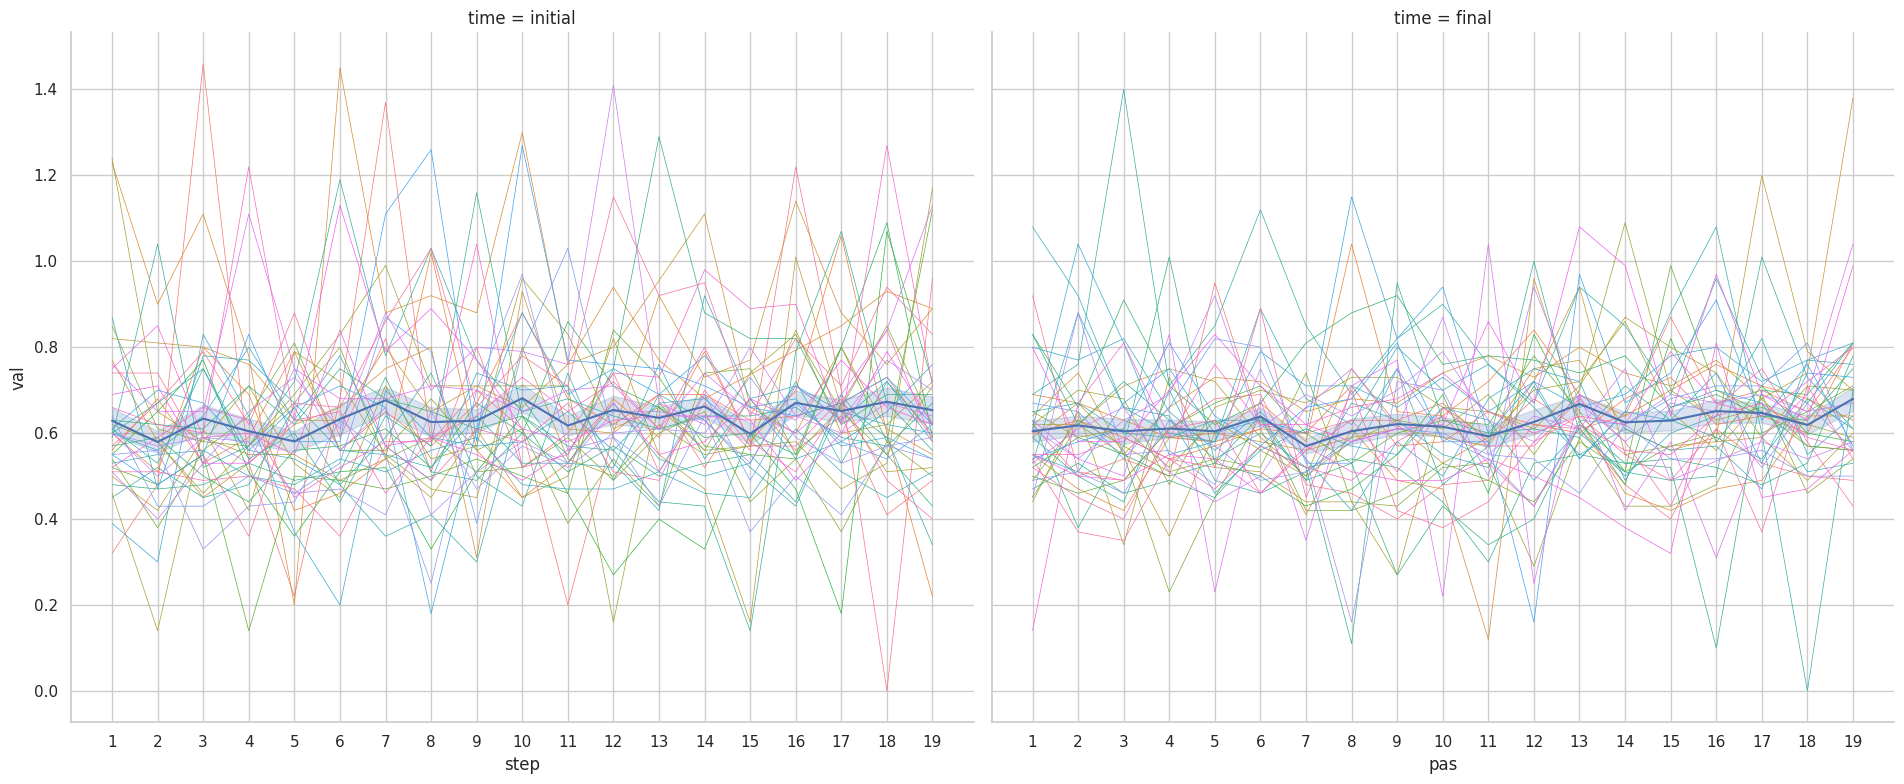

In [ ]:
grid = sns.FacetGrid(data = wm.loc[wm.val<1.5], col='time', height=8, aspect=1.2)
grid.map(sns.lineplot, 'step', 'val', 'id', legend=False, lw=0.5)
grid.map(sns.lineplot, 'step', 'val', errorbar='se')
plt.xlabel('pas')
plt.ylabel('timp')
# plt.savefig('facetgrid-spagetti.svg', bbox_inches = 'tight')

Text(528.1979166666667, 0.5, 'timp (s)')

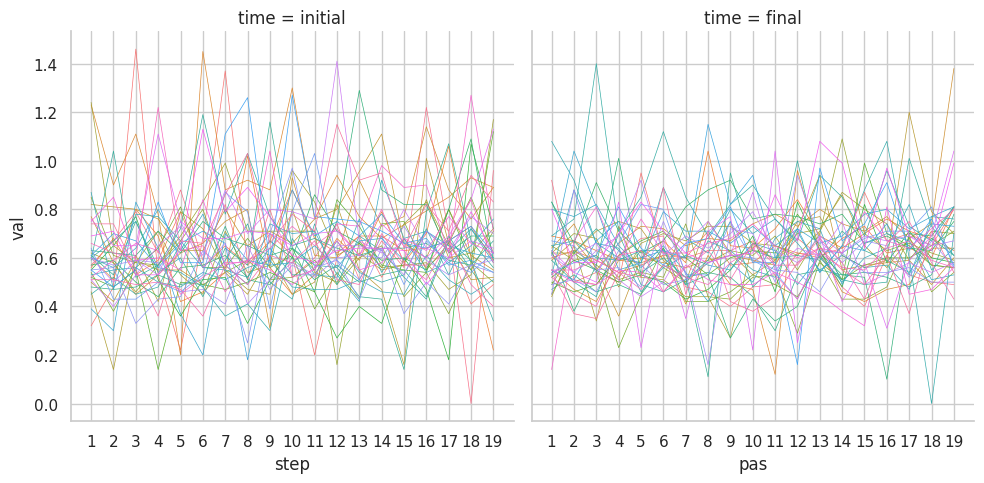

In [54]:
sns.relplot(data=wm.loc[wm.val<1.5], x='step', y='val', hue='id',
            col='time', legend=False, kind='line', lw=0.5)
plt.xlabel('pas')
plt.ylabel('timp (s)')

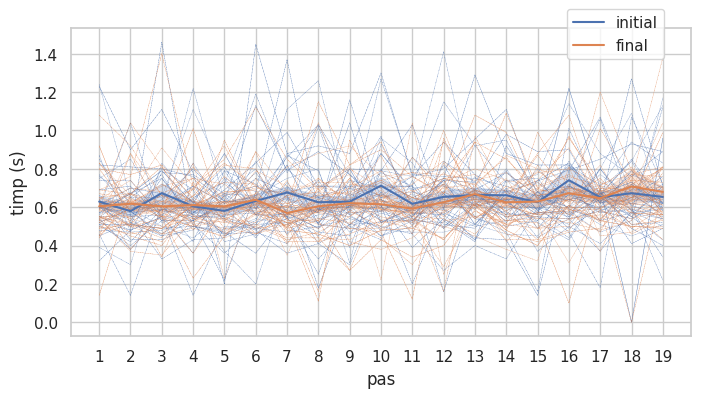

In [ ]:
sns.set(rc={"figure.figsize":(8,4)})
sns.set_style("whitegrid")
sns.lineplot(wm.loc[wm.val<1.5], x='step', y='val', style ='id', hue='time', lw=0.3, legend=False)
sns.lineplot(wm, x='step', y='val', hue ='time', errorbar='se')
plt.legend(loc=[0.8,0.9])
plt.xlabel('pas')
plt.ylabel('timp (s)')
# plt.savefig('spagetti.svg', bbox_inches = 'tight')

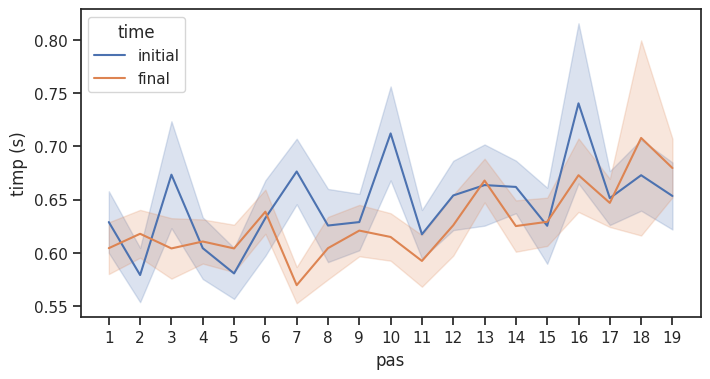

In [ ]:
sns.set(rc={"figure.figsize":(8,4)})
sns.set_style("ticks")
sns.lineplot(wm, x='step', y='val', hue ='time', errorbar='se')
plt.xlabel('pas')
plt.ylabel('timp (s)')
# plt.savefig('lineplot.svg', bbox_inches = 'tight')

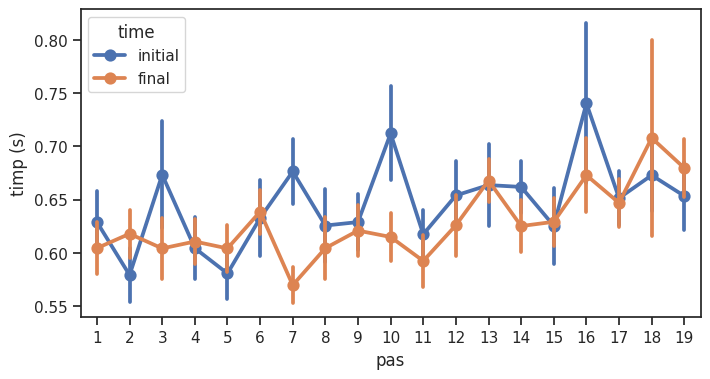

In [ ]:
sns.set(rc={"figure.figsize":(8,4)})
sns.set_style("ticks")
sns.pointplot(wm, x="step", y="val", hue="time", errorbar='se')
plt.xlabel('pas')
plt.ylabel('timp (s)')
# plt.savefig('pointplot.svg', bbox_inches = 'tight')

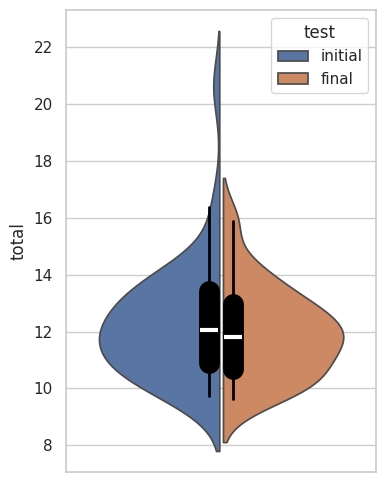

In [ ]:
sns.set(rc={"figure.figsize":(4,6)})
sns.set_style("whitegrid")
sns.violinplot(w, y="total", hue='time', split=True,
               gap=0.03, inner_kws=dict(box_width=15, whis_width=2, color="0"))
plt.legend(title='test')
# plt.savefig('violinplot.svg', bbox_inches = 'tight')

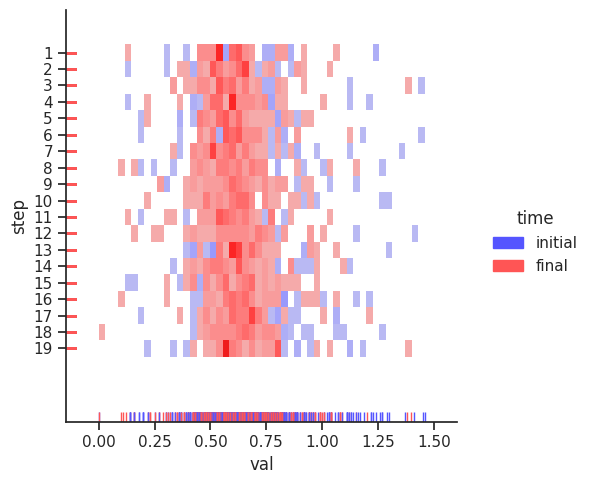

In [59]:
sns.set(rc={"figure.figsize":(6,6)})
sns.set_style("ticks")
sns.displot(wm.drop(wm.loc[wm.val > 1.5].index), x='val', y='step', hue='time', rug='True', palette='seismic', legend=True)

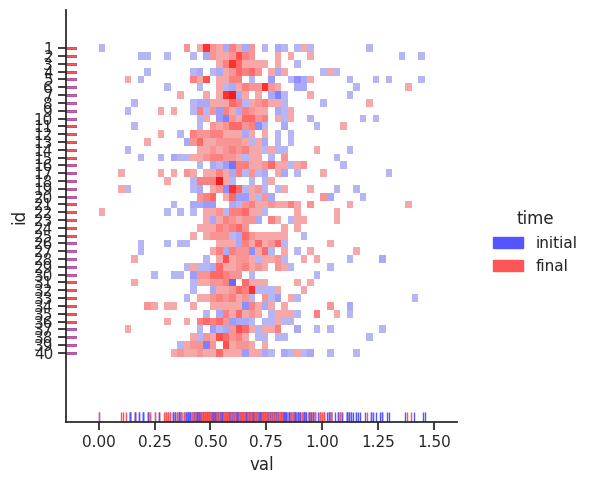

In [65]:
sns.set(rc={"figure.figsize":(6,6)})
sns.set_style("ticks")
sns.displot(wm.drop(wm.loc[wm.val > 1.5].index), x='val', y='id', hue='time', rug='True', palette='seismic', legend=True)